In [2]:
import numpy as np
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import traceback

from pathlib import Path
from IPython.display import clear_output
from seppy.util import resample_df
from solo_epd_loader import epd_load
from matplotlib.colors import LogNorm

from aipad.pad_imputation import (
    convert_to_bool_coverage, load_wind_event, coverage_overlap, 
    load_random_file, pad_histogram
)

from aipad.spacecrafts import SoloConstants, WindConstants

solo = SoloConstants()
wind = WindConstants()

### Generate coverages

In [2]:
import logging
filehandler = logging.FileHandler(filename="./logs/solo_cov.log", encoding="utf-8")
streamhandler = logging.StreamHandler(sys.stdout)
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(message)s', datefmt='%m/%d/%Y %H:%M:%S', handlers=[filehandler, streamhandler], force=True)

bin_width_deg = 1
time_avg_min = 1
root_path = Path(".")
data_path = root_path / "data" / "sc"
save_path = Path(".") / "data" / "coverages" / f"{time_avg_min}min_{bin_width_deg}deg"

data_path.mkdir(exist_ok=True)
save_path.mkdir(exist_ok=True)

max_days = (solo.mission_end - solo.mission_start).days
name = solo.name

try:
    start = int(sys.argv[1])
except (IndexError, ValueError):
    start = 0

logging.info(f"Run start: {start}")

for i in range(start, max_days):
    logging.info(f"Day {i}")
    
    date = solo.mission_start + dt.timedelta(days=i)
    logging.info(f"Forming {name} coverages from date {date}")
    try:
        df, df_rtn, df_hci, energies_dict, metadata_dict = epd_load("ept", startdate=date, 
                                                                    level="l3", autodownload=True,
                                                                    path=str(data_path), pos_timestamp="start")

        if (len(df.index) // 60) < 12:
            logging.info(f"Day {i}: Data file not long enough to generate 12 hour coverage, skipping...")
            continue
        
        # if more than 20 % of data is missing, skip
        if np.mean(np.isnan(df.to_numpy())) > 0.20:
            logging.info(f"Day {i}: Over 20 % of the data is missing, skipping...")
            continue

        df = resample_df(df, resample=str(time_avg_min) + "min", pos_timestamp="start")
        ind = pd.MultiIndex.from_product([solo.sectors, ["min", "center", "max"]])
        df_cov = pd.DataFrame(index=df.index, columns=ind)

        for direction, pa_col, pa_sigma_col in zip(solo.sectors, solo.pitch_angle_mu_columns, 
                                                    solo.pitch_angle_sigma_columns):
            df_cov[(direction, "center")] = df[pa_col]
            df_cov[(direction, "min")] = df[pa_col] - df[pa_sigma_col]
            df_cov[(direction, "max")] = df[pa_col] + df[pa_sigma_col]

        X1, Y1, solo_cov = convert_to_bool_coverage(df_cov, sc=solo, bin_width_deg=bin_width_deg)

        # Generate 4 random 12 hour coverages
        
        for j in range(1, 5):
            random_start = np.random.randint(0, len(solo_cov) - 12*60//time_avg_min)
            cov = solo_cov[random_start:random_start+12*60//time_avg_min]
            logging.info(f"Generated coverage with shape {cov.shape}")
            np.save(save_path / f"{date.strftime("%Y%m%d")}_{time_avg_min}min_{bin_width_deg}deg_{j}", cov)

    except UnboundLocalError:
        logging.info(f"No data was found, skipping...")

    clear_output()

01/10/2026 19:06:13 Day 160
01/10/2026 19:06:13 Forming SolO coverages from date 2021-06-10 00:00:00


solo_L3_epd-ept-1min_20210610_V03.cdf: 582kB [00:00, 674kB/s]                             
Your resample option of '1min' is equal to the original data cadence of '0 days 00:01:00'. You should only average like this if you know EXACTLY what you are doing, as it could offset the position of the timestamps!

NOTE: Automatically detected columns with uncertainties: ['Electron_Corrected_Uncertainty_A_xx', 'Electron_Corrected_Uncertainty_D_xx', 'Electron_Corrected_Uncertainty_N_xx', 'Electron_Corrected_Uncertainty_S_xx', 'Electron_Uncertainty_A_xx', 'Electron_Uncertainty_D_xx', 'Electron_Uncertainty_N_xx', 'Electron_Uncertainty_S_xx', 'Ion_Uncertainty_A_xx', 'Ion_Uncertainty_D_xx', 'Ion_Uncertainty_N_xx', 'Ion_Uncertainty_S_xx', 'Pitch_Angle_Sigma_A', 'Pitch_Angle_Sigma_D', 'Pitch_Angle_Sigma_N', 'Pitch_Angle_Sigma_S']. Please report this behaviour if you think it is wrong!


KeyboardInterrupt: 

### Generate full and reduced intensity histograms, save intensity data

In [5]:
import logging
filehandler = logging.FileHandler(filename="./logs/histogram_forming.log", encoding="utf-8")
streamhandler = logging.StreamHandler(sys.stdout)
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(message)s', datefmt='%m/%d/%Y %H:%M:%S', handlers=[filehandler, streamhandler], force=True)

year = 2012

energy_channel = 3
bin_width_deg = 1
time_avg_min = 1

data_path = Path("./data/datafiles")
cov_path = Path("./data/coverages") / f"{time_avg_min}min_{bin_width_deg}deg"
event_path = Path("./data/event_lists")

save_path = Path("./data/intensities") / f"{time_avg_min}min_{bin_width_deg}deg"
save_path.mkdir(exist_ok=True)

# full_path = Path("./data/intensities/full") / f"{time_avg_min}min_{bin_width_deg}deg"
# reduced_path = Path("./data/intensities/reduced") / f"{time_avg_min}min_{bin_width_deg}deg"
# full_path.mkdir(exist_ok=True)
# reduced_path.mkdir(exist_ok=True)

try:
    df = pd.read_csv(event_path / f"wind_events_{year}.csv", delimiter=",")

    df_ = df

    for index, data in df_.iterrows():
        solo_cov_bool = load_random_file(cov_path)
        
        onset_dt = pd.to_datetime(df.iloc[index,1]) + pd.to_timedelta(df.iloc[index,2])
        if onset_dt < dt.datetime(2012, 8, 2):  # TODO: "saving" progress
            continue
        start = onset_dt - pd.Timedelta(hours=2)
        end = onset_dt + pd.Timedelta(hours=10)

        wind_event = load_wind_event(str(data_path), "Wind 3DP", start, end, "e", channels=energy_channel, averaging=f"{time_avg_min}min")
        wind_cov = wind_event.coverage
        X, Y, wind_cov_bool = convert_to_bool_coverage(wind_cov, wind, bin_width_deg=bin_width_deg)

        #cov_arr, reshaped = coverage_overlap(solo_cov_bool, wind_cov_bool)
        # TODO: for now, just skip if there's a shape mismatch. Need to think this through
        try:
            assert solo_cov_bool.shape == wind_cov_bool.shape
        except AssertionError:
            clear_output()
            logging.info(f"Coverage shape mismatch: SolO {solo_cov_bool.shape}, Wind {wind_cov_bool.shape} ({onset_dt})")
            continue

        cov_arr = solo_cov_bool & wind_cov_bool
        
        hist = pad_histogram(wind, wind_event.I_data, wind_cov, bin_width_deg)
        reduced_hist = np.where(cov_arr == True, hist, np.nan)

        logging.info(f"{hist.shape}, {reduced_hist.shape}")
        np.savez(save_path / f"Wind_{onset_dt.strftime("%Y%m%d-%H%M%S")}_{time_avg_min}min_{bin_width_deg}deg", 
                 allow_pickle=False, full=hist, reduced=reduced_hist, intensity_data=wind_event.I_data)
        #np.save(reduced_path / f"Wind_{onset_dt.strftime("%Y%m%d-%H%M%S")}_{time_avg_min}min_{bin_width_deg}deg_reduced", reduced_hist, allow_pickle=False)
        
        # TODO metadata (spacecraft, instrument, averaging, channels etc.)
        clear_output()
        logging.info(f"Histogram formed successfully ({onset_dt})")

except FileNotFoundError:
    logging.info(f"No data found for given year! ({year})")

01/11/2026 21:16:47 Histogram formed successfully (2012-12-20 22:00:00)


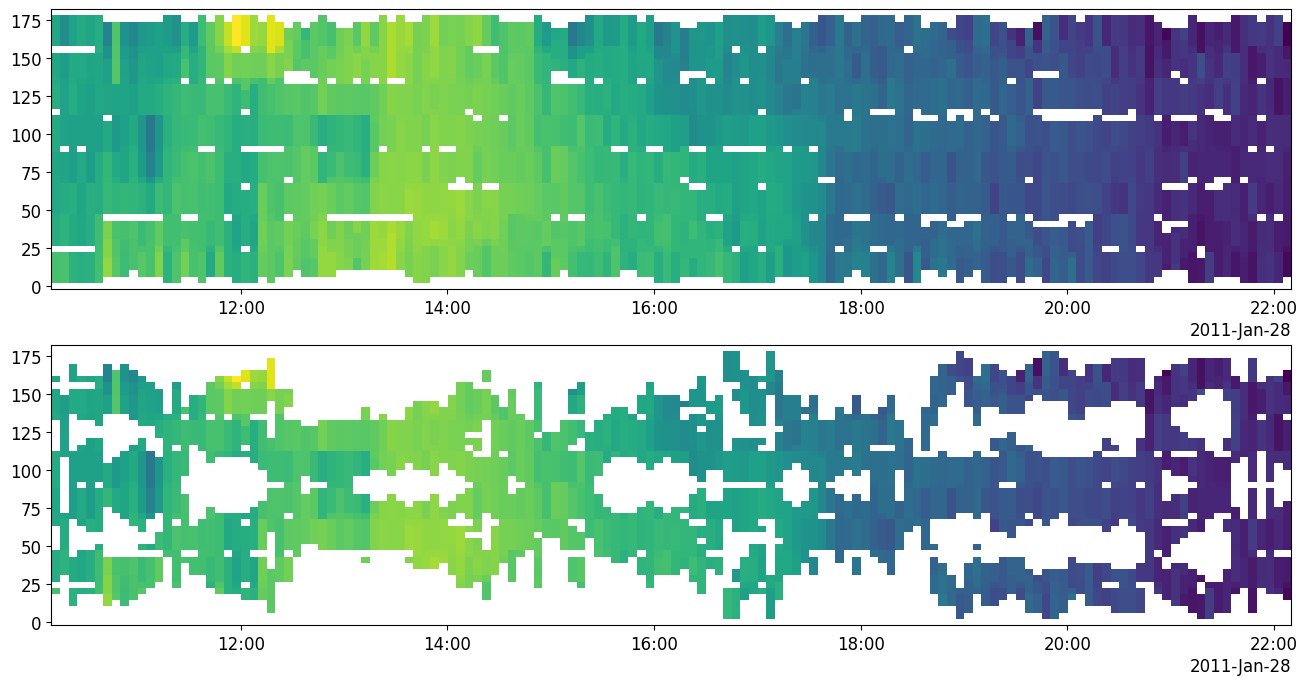

In [6]:
fig, axs = plt.subplots(nrows=2, figsize=(16,8))

axs[0].pcolormesh(X, Y, hist, norm=LogNorm())
axs[1].pcolormesh(X, Y, reduced_hist, norm=LogNorm())